# Goal Type x Focus effect

Import Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Combined Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [52]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

In [53]:
subgroup_theoretical= subgroup_theoretical[subgroup_theoretical["Response_Full"]!= "missing_response"].copy()

1. Contingency Table

In [54]:
contingency = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Focus"]],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Focus                                
goal_frequent     I               13        10       16
                  They            12         6        8
goal_non_frequent I               18         9       13
                  They            19         1        6
no_goal           I               22         5       11
                  They            12         7        7

2. Proportions

In [55]:
proportions = pd.crosstab(
    [subgroup_theoretical["Goal_Type"],subgroup_theoretical["Focus"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Focus                                 
goal_frequent     I         0.333333  0.256410  0.410256
                  They      0.461538  0.230769  0.307692
goal_non_frequent I         0.450000  0.225000  0.325000
                  They      0.730769  0.038462  0.230769
no_goal           I         0.578947  0.131579  0.289474
                  They      0.461538  0.269231  0.269231

3. Chi-Square Test

In [56]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 13.718
p-value: 0.1863
Degrees of freedom: 10


4. Expected Counts

In [57]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full            L1_transfer  L2_other    correct
Goal_Type         Focus                                  
goal_frequent     I        19.200000  7.600000  12.200000
                  They     12.800000  5.066667   8.133333
goal_non_frequent I        19.692308  7.794872  12.512821
                  They     12.800000  5.066667   8.133333
no_goal           I        18.707692  7.405128  11.887179
                  They     12.800000  5.066667   8.133333

In [58]:
print(expected_df < 5)

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Focus                                
goal_frequent     I            False     False    False
                  They         False     False    False
goal_non_frequent I            False     False    False
                  They         False     False    False
no_goal           I            False     False    False
                  They         False     False    False


5. Cramér's V

In [59]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.188


V = : the effect size is 

6. Standardized Residuals

In [60]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Focus                                 
goal_frequent     I        -1.414950  0.870572  1.087937
                  They     -0.223607  0.414644 -0.046752
goal_non_frequent I        -0.381356  0.431647  0.137725
                  They      1.732953 -1.806664 -0.748039
no_goal           I         0.761185 -0.883837 -0.257319
                  They     -0.223607  0.858906 -0.397396

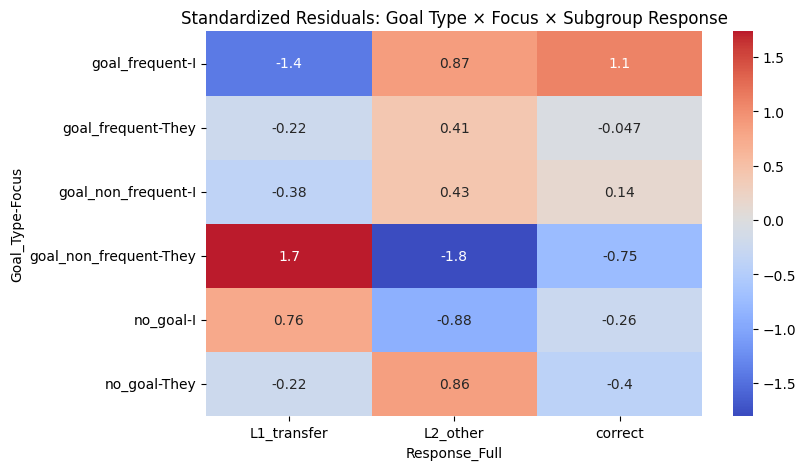

In [61]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Focus × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association


## Goal Behaviour Subgroup:
# Goals

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Split data into goals vs. no_goals

In [62]:
goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]!= "no_goal"].copy()

In [63]:
no_goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]== "no_goal"].copy()

1. Contingency Table

In [64]:
goal_contingency = pd.crosstab(
    [goals["Goal_Type"], goals["Focus"]],
    goals["Response_Full"]
)

goal_contingency

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Focus                                
goal_frequent     I               13        10       16
                  They            12         6        8
goal_non_frequent I               18         9       13
                  They            19         1        6

2. Proportions

In [65]:
goal_proportions = pd.crosstab(
    [goals["Goal_Type"],goals["Focus"]],
    goals["Response_Full"],
    normalize="index"
)

goal_proportions

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Focus                                 
goal_frequent     I         0.333333  0.256410  0.410256
                  They      0.461538  0.230769  0.307692
goal_non_frequent I         0.450000  0.225000  0.325000
                  They      0.730769  0.038462  0.230769

3. Chi-Square Test

In [66]:
chi2, p, dof, expected = chi2_contingency(goal_contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 11.188
p-value: 0.0827
Degrees of freedom: 6


no evidence. X2 is higher 

4. Expected Counts

In [67]:
goal_expected_df = pd.DataFrame(
    expected,
    index=goal_contingency.index,
    columns=goal_contingency.columns
)

goal_expected_df

Response_Full            L1_transfer  L2_other    correct
Goal_Type         Focus                                  
goal_frequent     I        18.458015  7.740458  12.801527
                  They     12.305344  5.160305   8.534351
goal_non_frequent I        18.931298  7.938931  13.129771
                  They     12.305344  5.160305   8.534351

In [68]:
print(goal_expected_df < 5)

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Focus                                
goal_frequent     I            False     False    False
                  They         False     False    False
goal_non_frequent I            False     False    False
                  They         False     False    False


There are no groups with fewer than  observations

5. Cramér's V

In [69]:
n = goal_contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(goal_contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.207


V = : the effect size is 

6. Standardized Residuals

In [70]:
goal_residuals = (
    goal_contingency - expected
) / np.sqrt(expected)

goal_residuals

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Focus                                 
goal_frequent     I        -1.270405  0.812152  0.893947
                  They     -0.087045  0.369644 -0.182912
goal_non_frequent I        -0.214042  0.376585 -0.035814
                  They      1.908453 -1.831418 -0.867524

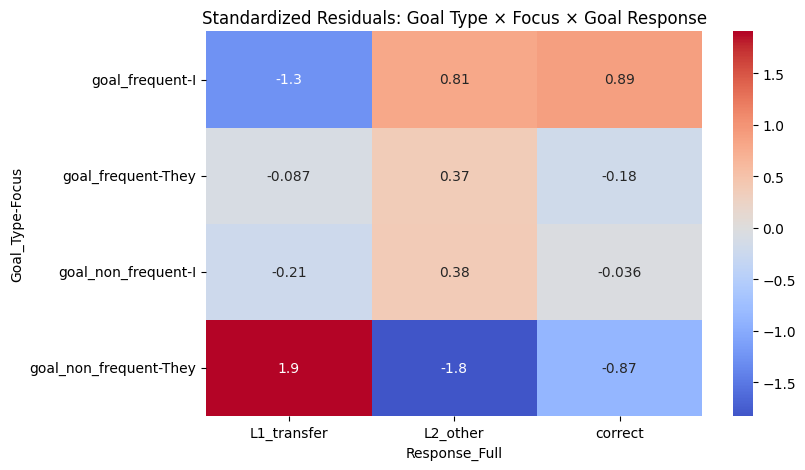

In [71]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    goal_residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Focus × Goal Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association